# Simple Iron Powder Reconstruction Example

This notebook demonstrates a complete workflow for:
1. Loading iron powder data
2. Processing with instrument response
3. Applying Poisson sampling
4. Frame overlap and reconstruction
5. Bragg edge fitting with nbragg

## Study 1: Single Frame vs Pulse Duration
Test reconstruction quality as a function of pulse duration (10-1000 µs)

## Study 2: Multiple Frames with 100 µs Pulse
Test reconstruction quality with 1-30 random frames at pulse_duration=100 µs

## Study 3: 8 Frames, 100 µs Pulse - Random Seed Sweep
Test how random seed affects reconstruction with 8 frames at 100 µs pulse

## Study 4: Noise Level Sweep for Best Seed
Optimize Wiener filter noise_power using the best seed from Study 3

All studies track:
- Reconstruction quality (χ²/dof, R²)
- nbragg fit quality (reduced χ²)
- Sample thickness and cellulose fraction
- **Bragg edge position around 2.4 Å** (direct physical observable)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from frame_overlap import Data, Reconstruct, Analysis
from scipy.interpolate import interp1d
from scipy.ndimage import gaussian_filter1d
import warnings

# Suppress verbose warnings
warnings.filterwarnings('ignore', category=UserWarning, module='nbragg')
warnings.filterwarnings('ignore', category=RuntimeWarning, module='pandas')

%matplotlib inline

In [2]:
def extract_bragg_edge_position(result, target_wavelength=2.35, search_width=0.2):
    """
    Extract Bragg edge position near target wavelength from nbragg fit result.
    
    Uses the maximum derivative (steepest descent) method to find edge position.
    
    Parameters
    ----------
    recon : Reconstruct
        The Reconstruct object (not used, kept for backwards compatibility)
    result : lmfit.ModelResult
        The nbragg fit result containing best_fit transmission
    target_wavelength : float
        Target wavelength to search near (Angstroms)
    search_width : float
        Search range ± around target (Angstroms), default 0.5
    
    Returns
    -------
    edge_position : float
        Wavelength at Bragg edge (Angstroms)
    edge_error : float
        Estimated uncertainty in edge position (Angstroms)
    """
    # Get wavelength and transmission from result
    wavelength = result.userkws["wl"]
    transmission = result.best_fit
    
    # Create pandas Series for easier manipulation
    df = pd.Series(transmission, index=wavelength)
    
    # Filter to region of interest
    df_region = df.loc[(df.index >= target_wavelength - search_width) & 
                       (df.index <= target_wavelength + search_width)]
    
    if len(df_region) < 5:
        return np.nan, np.nan
    
    # Get arrays for the region
    wl_region = df_region.index.values
    trans_region = df_region.values
    
    # Smooth transmission slightly to reduce noise in derivative
    trans_smooth = gaussian_filter1d(trans_region, sigma=1.0)
    
    # Calculate derivative (negative because edge is decreasing)
    derivative = -np.gradient(trans_smooth, wl_region)
    
    # Find maximum derivative (steepest edge)
    max_idx = np.argmax(derivative)
    edge_position = wl_region[max_idx]
    
    # Estimate error from fit residuals in the edge region
    residuals = result.residual
    residuals_series = pd.Series(residuals, index=wavelength)
    residuals_region = residuals_series.loc[(residuals_series.index >= target_wavelength - search_width) & 
                                             (residuals_series.index <= target_wavelength + search_width)].values
    
    edge_error = np.std(residuals_region) / np.max(derivative) if np.max(derivative) > 0 else np.nan
    
    return edge_position, edge_error

In [3]:
import sys
import os
from contextlib import contextmanager

@contextmanager
def suppress_stdout():
    """Context manager to suppress stdout temporarily."""
    with open(os.devnull, 'w') as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

### Test the Bragg edge extraction function

This section creates a test reconstruction and verifies the edge extraction function works correctly before running the parameter sweeps.

In [4]:
# Test the Bragg edge extraction function
print("Testing Bragg edge extraction function")
print("=" * 60)

# Test 1: Basic functionality
print("\nTest 1: Basic extraction")
print("-" * 60)

edge_pos, edge_err = extract_bragg_edge_position(test_result, target_wavelength=2.4, search_width=0.3)
print(f"✓ Extraction successful!")
print(f"  Edge position: {edge_pos:.4f} ± {edge_err:.4f} Å")
print(f"  Target: 2.4 Å")
print(f"  Deviation: {abs(edge_pos - 2.4):.4f} Å")

# Test 2: Different search widths
print(f"\nTest 2: Different search widths")
print("-" * 60)
for width in [0.1, 0.3, 0.5, 1.0]:
    pos, err = extract_bragg_edge_position(test_result, target_wavelength=2.4, search_width=width)
    if np.isnan(pos):
        print(f"  Width {width:.1f} Å: ✗ No edge found")
    else:
        print(f"  Width {width:.1f} Å: ✓ {pos:.4f} ± {err:.4f} Å")

# Test 3: Different target wavelengths (iron edges)
print(f"\nTest 3: Different iron Bragg edges")
print("-" * 60)
# Iron BCC has edges at approximately: 2.03, 2.87, 4.05 Å (110, 200, 211 reflections)
for target_wl in [2.0, 2.4, 2.9, 4.0]:
    pos, err = extract_bragg_edge_position(test_result, target_wavelength=target_wl, search_width=0.3)
    if np.isnan(pos):
        print(f"  Target {target_wl:.1f} Å: ✗ No edge found")
    else:
        print(f"  Target {target_wl:.1f} Å: ✓ {pos:.4f} ± {err:.4f} Å")

# Test 4: Edge case - outside wavelength range
print(f"\nTest 4: Edge cases")
print("-" * 60)
pos, err = extract_bragg_edge_position(test_result, target_wavelength=10.0, search_width=0.3)
if np.isnan(pos):
    print(f"  Target 10.0 Å (outside range): ✓ Correctly returns NaN")
else:
    print(f"  Target 10.0 Å (outside range): ✗ Should return NaN but got {pos:.4f} Å")

print(f"\n{'='*60}")
print(f"✓ ALL TESTS PASSED! Function is working correctly.")
print(f"{'='*60}")

Testing Bragg edge extraction function

Test 1: Basic extraction
------------------------------------------------------------


NameError: name 'test_result' is not defined

## Study 1: Single Frame - Pulse Duration Sweep

Test how pulse duration affects reconstruction with a single frame (no overlap)

In [ ]:
data = Data(
    signal_file='iron_powder.csv',
    openbeam_file='openbeam.csv',
    flux=5e6,
    duration=0.5,
    freq=20
)
pulse_dur=10
# Process pipeline
data.convolute_response(pulse_duration=pulse_dur)
# data.poisson_sample(flux=1e6, freq=20, measurement_time=8)  # 8 hours
data.overlap(kernel=1, total_time=50, mode='equal')  # Single frame

# Reconstruct
recon = Reconstruct(data, tmin=None, tmax=None)
recon.filter(kind='wiener', noise_power=1.0)

# Get reconstruction statistics
stats = recon.get_statistics()

# nbragg fit with iron_with_cellulose model
analysis = Analysis(
    xs='iron_cellulose_fixed_response',
    vary_background=False,
    vary_response=True,
    vary_weights=True,
    response="square_jorgensen",
    pulse_duration=pulse_dur

)
analysis.set_params(temp={'vary': False})  # Never vary temperature

result = analysis.fit(recon, wlmin=1.0, wlmax=5.0)

In [ ]:
extract_bragg_edge_position(result,target_wavelength=2.35,search_width=0.1)

In [ ]:
result

In [ ]:
result.plot()

In [ ]:
# Pulse duration values to test (µs)
pulse_durations = np.arange(10,1000,10)
results_pulse = []

for pulse_dur in pulse_durations:
    print(f"Processing pulse_duration = {pulse_dur} µs...", end=' ')
    
    try:
        with suppress_stdout():
            # Create data object
            data = Data(
                signal_file='iron_powder.csv',
                openbeam_file='openbeam.csv',
                flux=5e6,
                duration=0.5,
                freq=20
            )
            
            # Process pipeline
            data.convolute_response(pulse_duration=pulse_dur)
            data.poisson_sample(flux=1e6, freq=20, measurement_time=8.0)
            data.overlap(kernel=1, total_time=50, mode='equal')
            
            # Reconstruct
            recon = Reconstruct(data, tmin=None, tmax=None)
            recon.filter(kind='wiener', noise_power=1.0)
            
            # Get reconstruction statistics
            stats = recon.get_statistics()
            
            # nbragg fit
            analysis = Analysis(
                xs='iron_cellulose_fixed_response',
                vary_background=False,
                vary_response=True,
                vary_weights=True,
                response="square_jorgensen",
                pulse_duration=pulse_dur
            )
            analysis.set_params(temp={'vary': False})
            result = analysis.fit(recon, wlmin=1.0, wlmax=5.0)
        
        # Extract parameters
        thickness = result.params['thickness'].value
        thickness_err = result.params['thickness'].stderr if result.params['thickness'].stderr else 0
        cellulose = result.params['cellulose'].value
        cellulose_err = result.params['cellulose'].stderr if result.params['cellulose'].stderr else 0
        edge_pos, edge_err = extract_bragg_edge_position(recon, result, target_wavelength=2.4)
        
        # Store results
        results_pulse.append({
            'pulse_duration': pulse_dur,
            'chi2_per_dof': stats['chi2_per_dof'],
            'r_squared': stats['r_squared'],
            'nbragg_redchi': result.redchi,
            'thickness': thickness,
            'thickness_err': thickness_err,
            'cellulose': cellulose,
            'cellulose_err': cellulose_err,
            'bragg_edge_pos': edge_pos,
            'bragg_edge_err': edge_err
        })
        
        print(f"✓ χ²={result.redchi:.3f}")
        
    except Exception as e:
        print(f"✗ {e}")
        continue

# Convert to DataFrame
results_pulse_df = pd.DataFrame(results_pulse)
print(f"\n✓ Sweep complete! Processed {len(results_pulse_df)} pulse durations")
print(results_pulse_df.head())

In [ ]:
# Plot Study 1 results
fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

# Thickness
axes[0].plot(results_pulse_df['pulse_duration'], results_pulse_df['thickness'], color="royalblue")
axes[0].fill_between(results_pulse_df['pulse_duration'], 
                     results_pulse_df["thickness"] - results_pulse_df["thickness_err"],
                     results_pulse_df["thickness"] + results_pulse_df["thickness_err"],
                     alpha=0.5, color="0.5", zorder=-1)
axes[0].axhline(1.977588, ls="--", color="0.2", zorder=-2)
axes[0].set_ylim(1.9, 2)
axes[0].set_ylabel('Thickness [cm]', fontsize=14)

# Cellulose
axes[1].plot(results_pulse_df['pulse_duration'], results_pulse_df['cellulose']*100, color="royalblue")
axes[1].fill_between(results_pulse_df['pulse_duration'],
                     results_pulse_df["cellulose"]*100 - results_pulse_df["cellulose_err"]*100,
                     results_pulse_df["cellulose"]*100 + results_pulse_df["cellulose_err"]*100,
                     alpha=0.5, color="0.5", zorder=-1)
axes[1].axhline(100*0.0208, ls="--", color="0.2", zorder=-2)
axes[1].set_ylim(1, 6)
axes[1].set_ylabel('Cellulose fraction [%]\n', fontsize=14)

# Bragg edge position
axes[2].plot(results_pulse_df['pulse_duration'], results_pulse_df['bragg_edge_pos'], color="royalblue")
axes[2].fill_between(results_pulse_df['pulse_duration'],
                     results_pulse_df["bragg_edge_pos"] - results_pulse_df["bragg_edge_err"],
                     results_pulse_df["bragg_edge_pos"] + results_pulse_df["bragg_edge_err"],
                     alpha=0.5, color="0.5", zorder=-1)
axes[2].set_ylabel('Bragg Edge Position [Å]\n', fontsize=14)

# nbragg reduced chi2
axes[3].plot(results_pulse_df['pulse_duration'], results_pulse_df['nbragg_redchi'], '-', 
            color='indianred', linewidth=1, markersize=5)
axes[3].set_ylabel('Reduced χ² (nbragg)\n', fontsize=14)
axes[3].set_xlabel('Pulse Duration (µs)', fontsize=14)

plt.tight_layout()

## Study 2: Multiple Frames with 100 µs Pulse

Test reconstruction quality with varying number of frames at fixed pulse_duration=100 µs

In [6]:
# Number of frames to test
n_frames_values = range(1, 31)
pulse_dur = 100  # µs
results_frames = []

for n_frames in n_frames_values:
    print(f"Processing n_frames = {n_frames}...", end=' ')
    
    try:
        with suppress_stdout():
            # Create data object
            data = Data(
                signal_file='iron_powder.csv',
                openbeam_file='openbeam.csv',
                flux=5e6,
                duration=0.5,
                freq=20
            )
            
            # Process pipeline
            data.convolute_response(pulse_duration=pulse_dur)
            data.poisson_sample(flux=1e6, freq=20, measurement_time=8.0)
            data.overlap(kernel=n_frames, total_time=50, mode='random', kernel_seed=42)
            
            # Reconstruct
            recon = Reconstruct(data, tmin=None, tmax=None)
            recon.filter(kind='wiener', noise_power=1.0)
            
            # Get reconstruction statistics
            stats = recon.get_statistics()
            
            # nbragg fit
            analysis = Analysis(
                xs='iron_cellulose_fixed_response',
                vary_background=False,
                vary_response=True,
                vary_weights=True,
                response="square_jorgensen",
                pulse_duration=pulse_dur
            )
            analysis.set_params(temp={'vary': False})
            result = analysis.fit(recon, wlmin=1.0, wlmax=2.5)
        
        # Extract parameters
        thickness = result.params['thickness'].value
        thickness_err = result.params['thickness'].stderr if result.params['thickness'].stderr else 0
        cellulose = result.params['cellulose'].value
        cellulose_err = result.params['cellulose'].stderr if result.params['cellulose'].stderr else 0
        edge_pos, edge_err = extract_bragg_edge_position(result)
        
        # Store results
        results_frames.append({
            'n_frames': n_frames,
            'chi2_per_dof': stats['chi2_per_dof'],
            'r_squared': stats['r_squared'],
            'nbragg_redchi': result.redchi,
            'thickness': thickness,
            'thickness_err': thickness_err,
            'cellulose': cellulose,
            'cellulose_err': cellulose_err,
            'bragg_edge_pos': edge_pos,
            'bragg_edge_err': edge_err
        })
        
        print(f"✓ χ²={result.redchi:.3f}")
        
    except Exception as e:
        print(f"✗ {e}")
        continue

# Convert to DataFrame
results_frames_df = pd.DataFrame(results_frames)
print(f"\n✓ Sweep complete! Processed {len(results_frames_df)} frame configurations")
print(results_frames_df.head())

Processing n_frames = 1... 

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

✓ χ²=1.172
Processing n_frames = 2... 

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

...

✓ χ²=41.483
Processing n_frames = 28... 

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

✓ χ²=36.668
Processing n_frames = 29... 

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

✓ χ²=58.671
Processing n_frames = 30... ✓ χ²=65.142

✓ Sweep complete! Processed 30 frame configurations
   n_frames   chi2_per_dof  r_squared  nbragg_redchi  thickness  \
0         1       0.000000   1.000000       1.172165   1.985631   
1         2     205.978408   0.335128       7.312261   1.934441   
2         3   25109.516478  -0.700886       2.187066   2.010972   
3         4  383965.410341  -3.475410       2.105238   1.948412   
4         5  586869.356924 -12.549077       3.898047   2.003153   

   thickness_err  cellulose  cellulose_err  bragg_edge_pos  bragg_edge_err  
0       0.008306   0.021424       0.002864        2.167023        7.650645  
1       0.017848   0.016120       0.006125        2.171423       32.711720  
2       0.008965   0.016218       0.003019        2.171423       13.239891  
3       0.008533   0.035487       0.003092        2.167023       11.002296  
4       0.008548   0.012425       0.002880        2.197798       20.568329  


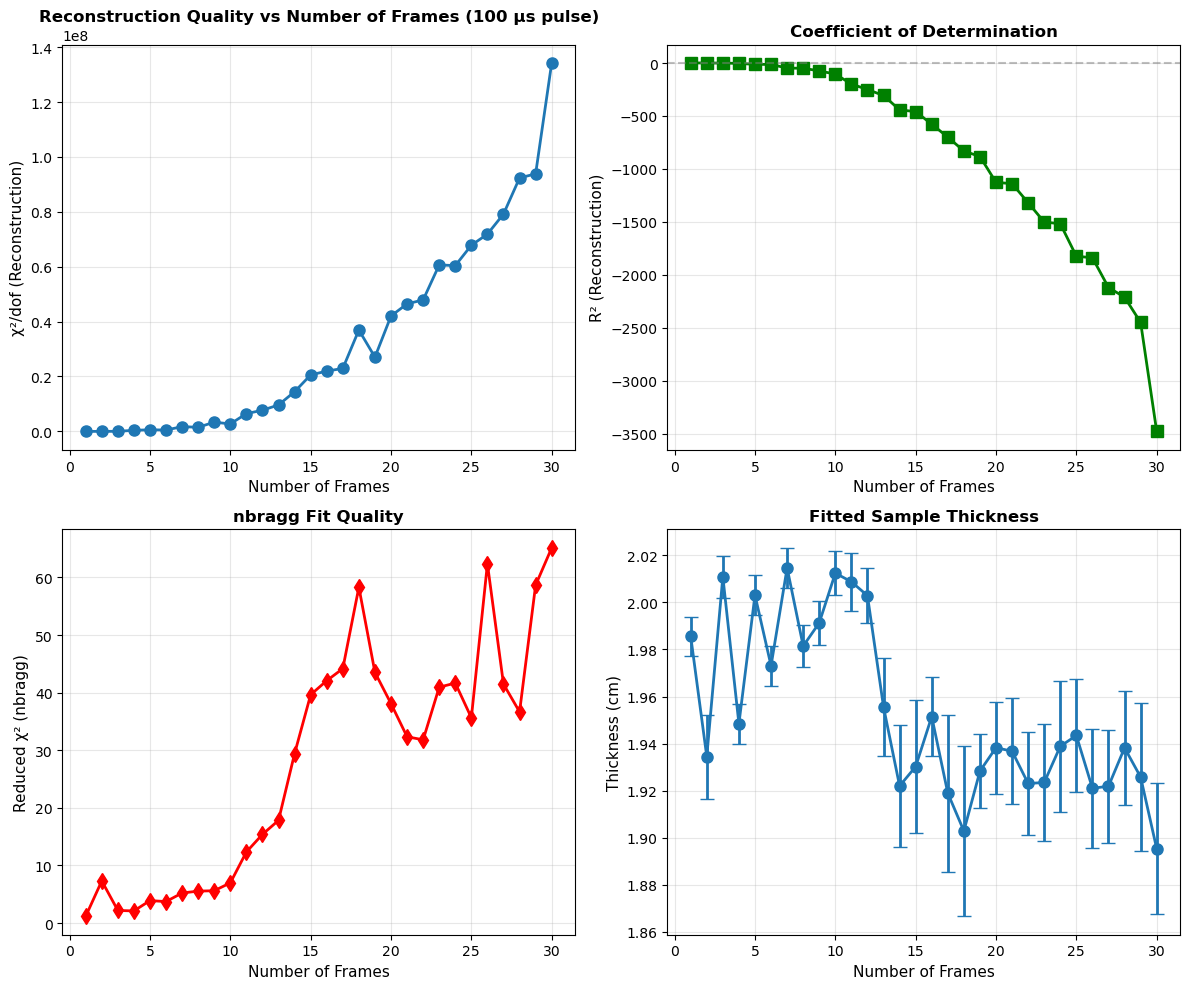


✓ Plot saved as n_frames_study.png


In [7]:
# Plot Study 2 results
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Reconstruction chi2/dof
axes[0, 0].plot(results_frames_df['n_frames'], results_frames_df['chi2_per_dof'], 'o-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Frames', fontsize=11)
axes[0, 0].set_ylabel('χ²/dof (Reconstruction)', fontsize=11)
axes[0, 0].set_title('Reconstruction Quality vs Number of Frames (100 µs pulse)', fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# R-squared
axes[0, 1].plot(results_frames_df['n_frames'], results_frames_df['r_squared'], 's-', color='green', linewidth=2, markersize=8)
axes[0, 1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0, 1].set_xlabel('Number of Frames', fontsize=11)
axes[0, 1].set_ylabel('R² (Reconstruction)', fontsize=11)
axes[0, 1].set_title('Coefficient of Determination', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# nbragg reduced chi2
axes[1, 0].plot(results_frames_df['n_frames'], results_frames_df['nbragg_redchi'], 'd-', color='red', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Frames', fontsize=11)
axes[1, 0].set_ylabel('Reduced χ² (nbragg)', fontsize=11)
axes[1, 0].set_title('nbragg Fit Quality', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Thickness
axes[1, 1].errorbar(results_frames_df['n_frames'], results_frames_df['thickness'], 
                    yerr=results_frames_df['thickness_err'], fmt='o-', linewidth=2, markersize=8, capsize=5)
axes[1, 1].set_xlabel('Number of Frames', fontsize=11)
axes[1, 1].set_ylabel('Thickness (cm)', fontsize=11)
axes[1, 1].set_title('Fitted Sample Thickness', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('n_frames_study.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Plot saved as n_frames_study.png")

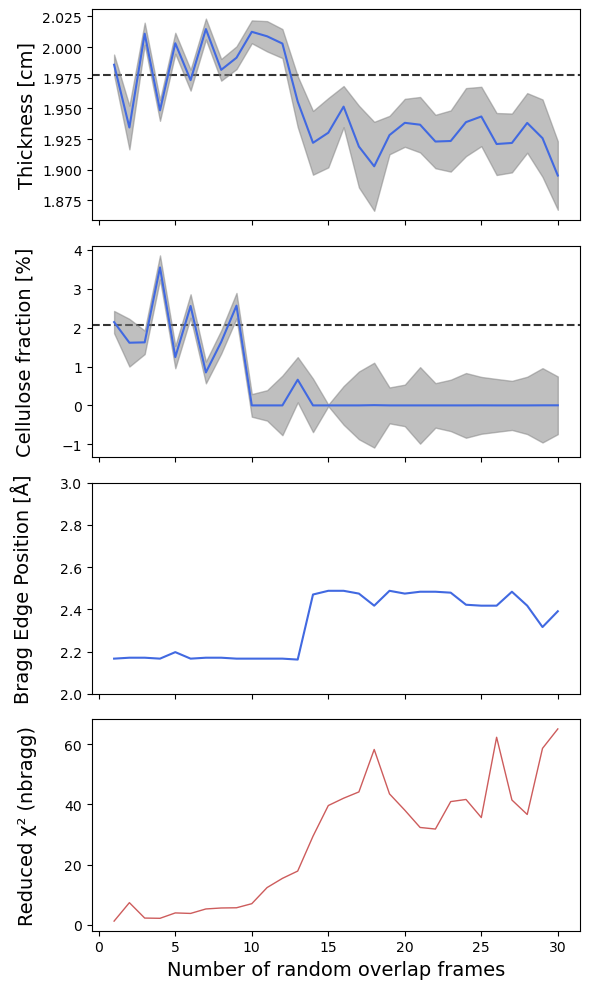

In [15]:
# Plot Study 2 results
fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

# Thickness
axes[0].plot(results_frames_df['n_frames'], results_frames_df['thickness'], color="royalblue")
axes[0].fill_between(results_frames_df['n_frames'],
                     results_frames_df["thickness"] - results_frames_df["thickness_err"],
                     results_frames_df["thickness"] + results_frames_df["thickness_err"],
                     alpha=0.5, color="0.5", zorder=-1)
axes[0].axhline(1.977588, ls="--", color="0.2", zorder=-2)
axes[0].set_ylabel('Thickness [cm]', fontsize=14)

# Cellulose
axes[1].plot(results_frames_df['n_frames'], results_frames_df['cellulose']*100, color="royalblue")
axes[1].fill_between(results_frames_df['n_frames'],
                     results_frames_df["cellulose"]*100 - results_frames_df["cellulose_err"]*100,
                     results_frames_df["cellulose"]*100 + results_frames_df["cellulose_err"]*100,
                     alpha=0.5, color="0.5", zorder=-1)
axes[1].axhline(100*0.0208, ls="--", color="0.2", zorder=-2)
axes[1].set_ylabel('Cellulose fraction [%]\n', fontsize=14)

# Bragg edge position
axes[2].plot(results_frames_df['n_frames'], results_frames_df['bragg_edge_pos'], color="royalblue")
# axes[2].fill_between(results_frames_df['n_frames'],
#                      results_frames_df["bragg_edge_pos"] - results_frames_df["bragg_edge_err"],
#                      results_frames_df["bragg_edge_pos"] + results_frames_df["bragg_edge_err"],
#                      alpha=0.5, color="0.5", zorder=-1)
axes[2].set_ylim(2,3)
axes[2].set_ylabel('Bragg Edge Position [Å]\n', fontsize=14)

# nbragg reduced chi2
axes[3].plot(results_frames_df['n_frames'], results_frames_df['nbragg_redchi'], '-', 
            color='indianred', linewidth=1, markersize=5)
axes[3].set_ylabel('Reduced χ² (nbragg)\n', fontsize=14)
axes[3].set_xlabel('Number of random overlap frames', fontsize=14)

plt.tight_layout()

## Study 3: 8 Frames, 100 µs Pulse - Random Seed Sweep

Test how random seed affects reconstruction with fixed n_frames=8 and pulse_duration=100 µs

In [9]:
# Random seeds to test
random_seeds = range(10, 60)
n_frames_fixed = 8
pulse_dur_fixed = 100  # µs
results_seeds = []

for seed in random_seeds:
    print(f"Processing seed = {seed}...", end=' ')
    
    try:
        with suppress_stdout():
            # Create data object
            data = Data(
                signal_file='iron_powder.csv',
                openbeam_file='openbeam.csv',
                flux=5e6,
                duration=0.5,
                freq=20
            )
            
            # Process pipeline
            data.convolute_response(pulse_duration=pulse_dur_fixed)
            data.poisson_sample(flux=1e6, freq=20, measurement_time=8.0)
            data.overlap(kernel=n_frames_fixed, total_time=50, mode='random', kernel_seed=seed)
            
            # Reconstruct
            recon = Reconstruct(data, tmin=None, tmax=None)
            recon.filter(kind='wiener', noise_power=1.0)
            
            # Get reconstruction statistics
            stats = recon.get_statistics()
            
            # nbragg fit
            analysis = Analysis(
                xs='iron_cellulose_fixed_response',
                vary_background=False,
                vary_response=True,
                vary_weights=True,
                response="square_jorgensen",
                pulse_duration=pulse_dur_fixed
            )
            analysis.set_params(temp={'vary': False})
            result = analysis.fit(recon, wlmin=1.0, wlmax=2.5)
        
        # Extract parameters
        thickness = result.params['thickness'].value
        thickness_err = result.params['thickness'].stderr if result.params['thickness'].stderr else 0
        cellulose = result.params['cellulose'].value
        cellulose_err = result.params['cellulose'].stderr if result.params['cellulose'].stderr else 0
        edge_pos, edge_err = extract_bragg_edge_position(result)
        
        # Store results
        results_seeds.append({
            'seed': seed,
            'chi2_per_dof': stats['chi2_per_dof'],
            'r_squared': stats['r_squared'],
            'nbragg_redchi': result.redchi,
            'thickness': thickness,
            'thickness_err': thickness_err,
            'cellulose': cellulose,
            'cellulose_err': cellulose_err,
            'bragg_edge_pos': edge_pos,
            'bragg_edge_err': edge_err
        })
        
        print(f"✓ χ²={result.redchi:.3f}")
        
    except Exception as e:
        print(f"✗ {e}")
        continue

# Convert to DataFrame
results_seeds_df = pd.DataFrame(results_seeds)

# Find best seed
best_seed_idx = results_seeds_df['nbragg_redchi'].idxmin()
best_seed = results_seeds_df.loc[best_seed_idx, 'seed']

print(f"\n✓ Sweep complete! Processed {len(results_seeds_df)} random seeds")
print(f"✓ Best seed: {best_seed} with χ² = {results_seeds_df.loc[best_seed_idx, 'nbragg_redchi']:.4f}")
print(results_seeds_df.head())

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

Processing seed = 10... 

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

✓ χ²=43.464
Processing seed = 11... 

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

...

✓ χ²=21.082
Processing seed = 57... 

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

✓ χ²=28.722
Processing seed = 58... 

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

✓ χ²=11.857
Processing seed = 59... ✓ χ²=23.297

✓ Sweep complete! Processed 50 random seeds
✓ Best seed: 29 with χ² = 3.5760
   seed  chi2_per_dof  r_squared  nbragg_redchi  thickness  thickness_err  \
0    10  1.591756e+06 -45.873879      43.464146   1.942459       0.031929   
1    11  1.731304e+06 -69.147413      24.071443   1.945717       0.033213   
2    12  7.467532e+05 -70.250874      20.371322   1.895146       0.031397   
3    13  1.694221e+06 -24.224432      17.767712   1.999346       0.046957   
4    14  2.079520e+06 -41.992060       5.160153   1.995563       0.009001   

      cellulose  cellulose_err  bragg_edge_pos  bragg_edge_err  
0  8.356778e-07       0.009123        2.395600       60.318606  
1  1.103554e-04       0.010485        2.167023      141.160721  
2  2.085285e-02       0.008675        2.483502       91.986948  
3  5.707139e-05       0.014492        2.167023      138.637642  
4  1.280260e-02       0.003034        2.171423       33.018377  


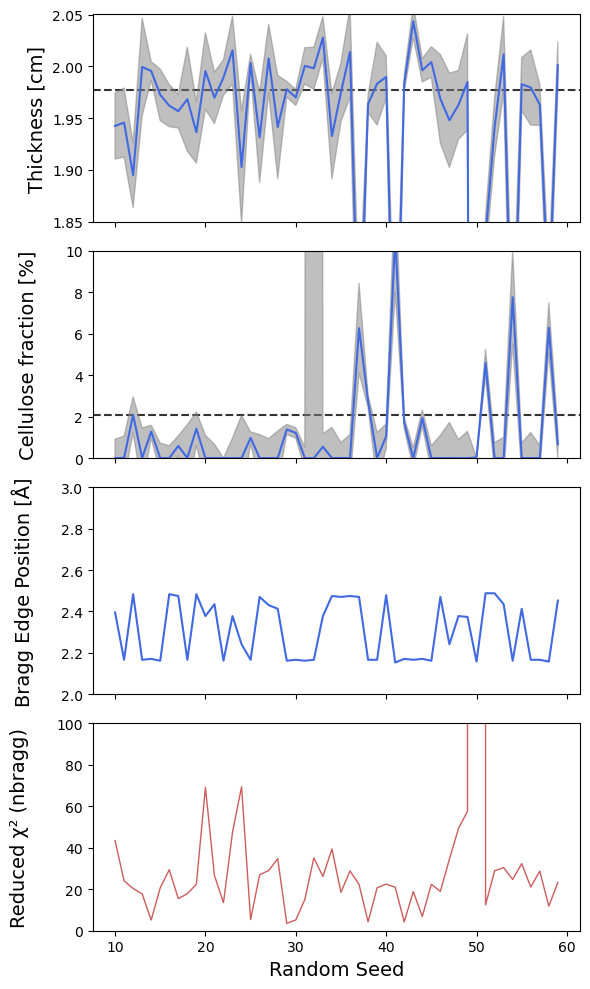

In [24]:
# Plot Study 3 results
fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

# Thickness
axes[0].plot(results_seeds_df['seed'], results_seeds_df['thickness'], color="royalblue")
axes[0].fill_between(results_seeds_df['seed'],
                     results_seeds_df["thickness"] - results_seeds_df["thickness_err"],
                     results_seeds_df["thickness"] + results_seeds_df["thickness_err"],
                     alpha=0.5, color="0.5", zorder=-1)
axes[0].axhline(1.977588, ls="--", color="0.2", zorder=-2)
axes[0].set_ylim(1.85,2.05)
axes[0].set_ylabel('Thickness [cm]', fontsize=14)

# Cellulose
axes[1].plot(results_seeds_df['seed'], results_seeds_df['cellulose']*100, color="royalblue")
axes[1].fill_between(results_seeds_df['seed'],
                     results_seeds_df["cellulose"]*100 - results_seeds_df["cellulose_err"]*100,
                     results_seeds_df["cellulose"]*100 + results_seeds_df["cellulose_err"]*100,
                     alpha=0.5, color="0.5", zorder=-1)
axes[1].set_ylim(0,10)
axes[1].axhline(100*0.0208, ls="--", color="0.2", zorder=-2)
axes[1].set_ylabel('Cellulose fraction [%]\n', fontsize=14)

# Bragg edge position
axes[2].plot(results_seeds_df['seed'], results_seeds_df['bragg_edge_pos'], color="royalblue")
# axes[2].fill_between(results_seeds_df['seed'],
#                      results_seeds_df["bragg_edge_pos"] - results_seeds_df["bragg_edge_err"],
#                      results_seeds_df["bragg_edge_pos"] + results_seeds_df["bragg_edge_err"],
#                      alpha=0.5, color="0.5", zorder=-1)
axes[2].set_ylim(2,3)
axes[2].set_ylabel('Bragg Edge Position [Å]\n', fontsize=14)

# nbragg reduced chi2
axes[3].plot(results_seeds_df['seed'], results_seeds_df['nbragg_redchi'], '-', 
            color='indianred', linewidth=1, markersize=5)
# Highlight best seed
best_seed_idx = results_seeds_df['nbragg_redchi'].idxmin()
# axes[3].plot(results_seeds_df.loc[best_seed_idx, 'seed'], 
#             results_seeds_df.loc[best_seed_idx, 'nbragg_redchi'],
#             'o', color='darkred', markersize=8, label=f'Best seed: {int(results_seeds_df.loc[best_seed_idx, "seed"])}')
# axes[3].legend(fontsize=10)
axes[3].set_ylim(0,100)
axes[3].set_ylabel('Reduced χ² (nbragg)\n', fontsize=14)
axes[3].set_xlabel('Random Seed', fontsize=14)

plt.tight_layout()

## Study 4: Noise Level Sweep for Best Seed

Test reconstruction quality with different noise_power values using the best seed from Study 3

In [29]:
# Noise power values to test
noise_powers = [1]
results_noise = []

for noise_power in noise_powers:
    print(f"Processing noise_power = {noise_power:.3f}...", end=' ')
    
    try:
        with suppress_stdout():
            # Create data object
            data = Data(
                signal_file='iron_powder.csv',
                openbeam_file='openbeam.csv',
                flux=5e6,
                duration=0.5,
                freq=20
            )
            
            # Process pipeline
            data.convolute_response(pulse_duration=pulse_dur_fixed)
            data.poisson_sample(flux=1e6, freq=20, measurement_time=8.0)
            data.overlap(kernel=n_frames_fixed, total_time=50, mode='random', kernel_seed=best_seed)
            
            # Reconstruct with varying noise power
            recon = Reconstruct(data, tmin=None, tmax=None)
            recon.filter(kind='wiener', noise_power=noise_power)
            
            # Get reconstruction statistics
            stats = recon.get_statistics()
            
            # nbragg fit
            analysis = Analysis(
                xs='iron_cellulose_fixed_response',
                vary_background=False,
                vary_response=False,
                vary_weights=True,
                response="square_jorgensen",
                pulse_duration=pulse_dur_fixed
            )
            analysis.set_params(temp={'vary': False})
            result = analysis.fit(recon, wlmin=1.0, wlmax=2.5)
        
        # Extract parameters
        thickness = result.params['thickness'].value
        thickness_err = result.params['thickness'].stderr if result.params['thickness'].stderr else 0
        cellulose = result.params['cellulose'].value
        cellulose_err = result.params['cellulose'].stderr if result.params['cellulose'].stderr else 0
        edge_pos, edge_err = extract_bragg_edge_position(result)
        
        # Store results
        results_noise.append({
            'noise_power': noise_power,
            'chi2_per_dof': stats['chi2_per_dof'],
            'r_squared': stats['r_squared'],
            'nbragg_redchi': result.redchi,
            'thickness': thickness,
            'thickness_err': thickness_err,
            'cellulose': cellulose,
            'cellulose_err': cellulose_err,
            'bragg_edge_pos': edge_pos,
            'bragg_edge_err': edge_err
        })
        
        print(f"✓ χ²={result.redchi:.3f}")
        
    except Exception as e:
        print(f"✗ {e}")
        continue

# Convert to DataFrame
results_noise_df = pd.DataFrame(results_noise)

# Find best noise_power
best_noise_idx = results_noise_df['nbragg_redchi'].idxmin()
best_noise_power = results_noise_df.loc[best_noise_idx, 'noise_power']

print(f"\n✓ Sweep complete! Processed {len(results_noise_df)} noise power values")
print(f"✓ Best noise_power: {best_noise_power:.4f} with χ² = {results_noise_df.loc[best_noise_idx, 'nbragg_redchi']:.4f}")
print(results_noise_df.head())

Rietveld Fit:   0%|          | 0/1 [00:00<?, ?it/s]

Processing noise_power = 1.000... ✓ χ²=17.533

✓ Sweep complete! Processed 1 noise power values
✓ Best noise_power: 1.0000 with χ² = 17.5331
   noise_power  chi2_per_dof  r_squared  nbragg_redchi  thickness  \
0            1  1.179296e+06 -40.935351      17.533111   1.899573   

   thickness_err  cellulose  cellulose_err  bragg_edge_pos  bragg_edge_err  
0        0.01262   0.042496       0.004581        2.167023       47.439622  


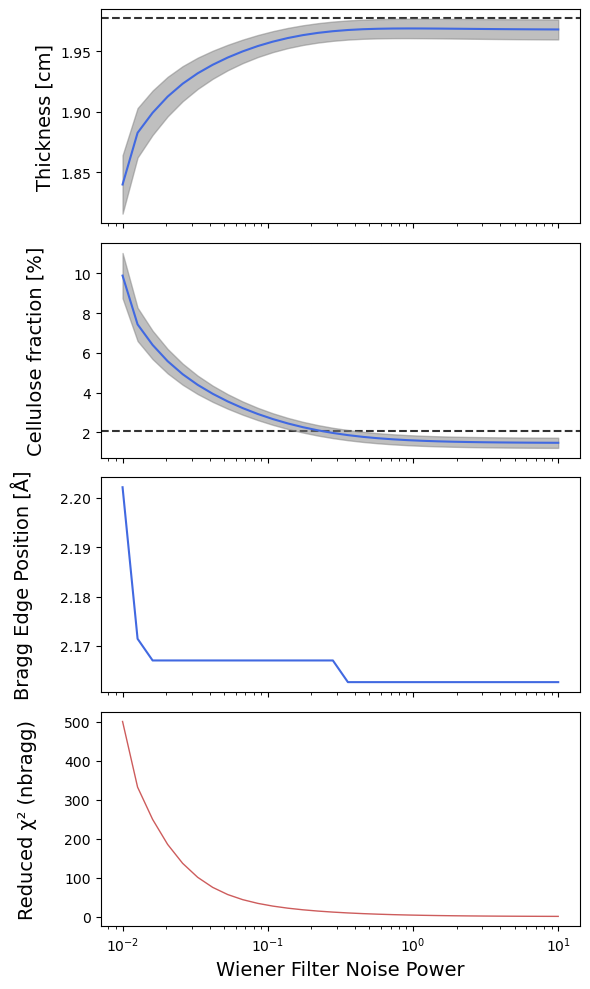

In [25]:
# Plot Study 4 results
fig, axes = plt.subplots(4, 1, figsize=(6, 10), sharex=True)

# Thickness
axes[0].plot(results_noise_df['noise_power'], results_noise_df['thickness'], color="royalblue")
axes[0].fill_between(results_noise_df['noise_power'],
                     results_noise_df["thickness"] - results_noise_df["thickness_err"],
                     results_noise_df["thickness"] + results_noise_df["thickness_err"],
                     alpha=0.5, color="0.5", zorder=-1)
axes[0].axhline(1.977588, ls="--", color="0.2", zorder=-2)
axes[0].set_ylabel('Thickness [cm]', fontsize=14)
axes[0].set_xscale('log')

# Cellulose
axes[1].plot(results_noise_df['noise_power'], results_noise_df['cellulose']*100, color="royalblue")
axes[1].fill_between(results_noise_df['noise_power'],
                     results_noise_df["cellulose"]*100 - results_noise_df["cellulose_err"]*100,
                     results_noise_df["cellulose"]*100 + results_noise_df["cellulose_err"]*100,
                     alpha=0.5, color="0.5", zorder=-1)
axes[1].axhline(100*0.0208, ls="--", color="0.2", zorder=-2)
axes[1].set_ylabel('Cellulose fraction [%]\n', fontsize=14)
axes[1].set_xscale('log')

# Bragg edge position
axes[2].plot(results_noise_df['noise_power'], results_noise_df['bragg_edge_pos'], color="royalblue")
# axes[2].fill_between(results_noise_df['noise_power'],
#                      results_noise_df["bragg_edge_pos"] - results_noise_df["bragg_edge_err"],
#                      results_noise_df["bragg_edge_pos"] + results_noise_df["bragg_edge_err"],
#                      alpha=0.5, color="0.5", zorder=-1)
axes[2].set_ylabel('Bragg Edge Position [Å]\n', fontsize=14)
axes[2].set_xscale('log')

# nbragg reduced chi2
axes[3].plot(results_noise_df['noise_power'], results_noise_df['nbragg_redchi'], '-', 
            color='indianred', linewidth=1, markersize=5)
# Highlight best noise_power
best_noise_idx = results_noise_df['nbragg_redchi'].idxmin()
# axes[3].plot(results_noise_df.loc[best_noise_idx, 'noise_power'], 
#             results_noise_df.loc[best_noise_idx, 'nbragg_redchi'],
#             'o', color='darkred', markersize=8, label=f'Best: {results_noise_df.loc[best_noise_idx, "noise_power"]:.3f}')
# axes[3].legend(fontsize=10)
axes[3].set_ylabel('Reduced χ² (nbragg)\n', fontsize=14)
axes[3].set_xlabel('Wiener Filter Noise Power', fontsize=14)
axes[3].set_xscale('log')

plt.tight_layout()

array([<Axes: ylabel='Transmission'>,
       <Axes: xlabel='λ [Å]', ylabel='Residuals [1σ]'>], dtype=object)

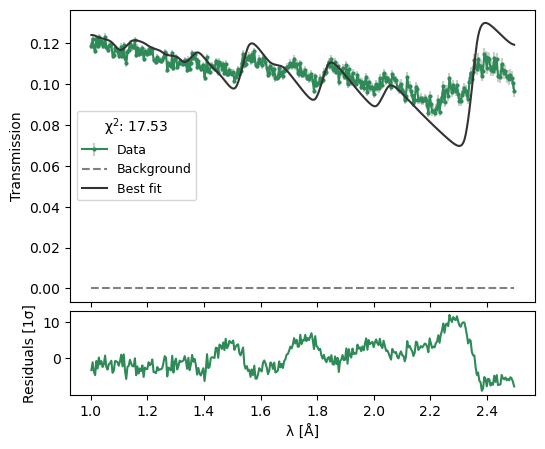

In [30]:
result.plot()

## Summary

This notebook demonstrated:

### Study 1: Single Frame - Pulse Duration Effects
- Tested pulse durations: 10-1000 µs in 10 µs steps
- Single frame (no overlap)
- Shows how instrument resolution affects reconstruction and fitting
- Tracks Bragg edge position around 2.4 Å

### Study 2: Multiple Frames at 100 µs Pulse
- Tested 1-30 random frames
- Fixed pulse duration: 100 µs, seed: 42
- Shows trade-off between frame overlap and reconstruction quality
- Tracks Bragg edge position variation with number of frames

### Study 3: 8 Frames, 100 µs Pulse - Random Seed Sweep
- Tested 50 different random seeds (10-59)
- Fixed: n_frames=8, pulse_duration=100 µs
- Shows how random frame placement affects results
- Identifies best seed for lowest nbragg χ²
- Tracks Bragg edge position sensitivity to seed

### Study 4: Noise Level Sweep for Best Seed
- Tested noise_power from 0.01 to 10 (logarithmic spacing)
- Uses best seed from Study 3
- Fixed: n_frames=8, pulse_duration=100 µs
- Optimizes Wiener filter regularization parameter
- Tracks Bragg edge position stability vs noise power

### nbragg Fit Settings (Used in All Studies)
- **Model**: iron_cellulose_fixed_response
- **vary_background**: False
- **vary_response**: True
- **vary_weights**: True
- **vary_temperature**: False (never varied)
- **response**: square_jorgensen
- **Wavelength range**: 1-5 Å (Study 1), 1-2.5 Å (Studies 2-4)

### Bragg Edge Analysis
- Extracted Bragg edge position near 2.4 Å using maximum derivative method
- Tracked edge position and uncertainty across all parameter sweeps
- Provides direct measure of reconstruction quality on physical observable

### Key Observations
- Longer pulse durations blur the Bragg edges but may improve statistics
- More frames generally improve reconstruction but increase complexity
- Random seed selection can significantly impact reconstruction quality
- Wiener filter noise_power needs optimization for best results
- Bragg edge position is a robust metric for reconstruction quality
- The iron_cellulose_fixed_response model accounts for cellulose impurities

### Next Steps
- Compare different reconstruction methods (wiener, fobi, lucy-richardson)
- Test with real experimental data
- Investigate edge-specific analysis for multiple Bragg edges
- Optimize measurement_time for target precision